# Notebook 14: Encoder Fine-Tuning + MLP-1 Head

## Purpose
Fine-tune `all-MiniLM-L6-v2` jointly with an MLP-1 head (384→256→2).
The same head provides training signal and final classification —
no discard-and-refit inconsistency from prior attempts.

## Design
- Staged unfreezing: 1, 2, 3, 6 layers — best condition identified by cal F1
- Best condition then evaluated under three augmentation regimes:
  a) 70B hard contrastive negatives (0.4≤τ≤0.9)
  b) 70B CoT positives (τ≥0.6)
  c) Combined (both simultaneously)
- Hypothesis: fine-tuned encoder resolves the geometric tension
  that caused combined augmentation to fail on frozen embeddings

## Evaluation
Threshold optimized on cal set. Metrics: P, R, F1 vs:
- Frozen MLP-1 baseline (F1=0.270)
- Best frozen augmentation result (MLP-1 + 70B CoT, F1=0.292)

In [4]:
# -----------------------------------------------
# Mount Google Drive — run once per Colab session
# -----------------------------------------------
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/hedging-txtclf-experiments')
print(f"Working directory: {os.getcwd()}")

Mounted at /content/drive
Working directory: /content/drive/MyDrive/hedging-txtclf-experiments


In [5]:
import os
for path in [
    "data/processed/train.parquet",
    "data/processed/calibration.parquet",
    "data/processed/test.parquet",
    "data/processed/embeddings/X_train.npy",
]:
    status = "✓" if os.path.exists(path) else "✗"
    print(f"{status} {path}")

✓ data/processed/train.parquet
✓ data/processed/calibration.parquet
✓ data/processed/test.parquet
✓ data/processed/embeddings/X_train.npy


In [6]:
import torch
from sentence_transformers import SentenceTransformer
import umap.umap_ as umap

print(f"Device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

Device: cuda
GPU: NVIDIA A100-SXM4-40GB


In [12]:
os.chdir('/content/drive/MyDrive/hedging-txtclf-experiments')
print(os.getcwd())
print(os.path.exists("data/processed/train.parquet"))

/content/drive/MyDrive/hedging-txtclf-experiments
True


In [14]:
# -----------------------------------------------
# Ensure correct working directory
# -----------------------------------------------
import os
if os.getcwd() != '/content/drive/MyDrive/hedging-txtclf-experiments':
    from google.colab import drive
    drive.mount('/content/drive')
    os.chdir('/content/drive/MyDrive/hedging-txtclf-experiments')
print(f"CWD: {os.getcwd()}")

CWD: /content/drive/MyDrive/hedging-txtclf-experiments


In [16]:
print(os.listdir('data/processed'))

['train.parquet', 'calibration.parquet', 'test.parquet', 'embeddings', 'finetuned']


In [17]:
# -----------------------------------------------
# Imports and setup
# -----------------------------------------------
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from copy import deepcopy

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torch.optim import AdamW

from sentence_transformers import SentenceTransformer
from sklearn.metrics import (
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    det_curve,
)
from sklearn.metrics.pairwise import cosine_similarity

import umap.umap_ as umap
import warnings
warnings.filterwarnings('ignore')

# -----------------------------------------------
# Device and seeds
# -----------------------------------------------
DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED     = 42
MODEL_NAME = 'all-MiniLM-L6-v2'

torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Device: {DEVICE}")
print(f"Model:  {MODEL_NAME}")

# -----------------------------------------------
# Load splits — raw sentences for encoder input,
# labels for training and evaluation
# -----------------------------------------------
BASE = '/content/drive/MyDrive/hedging-txtclf-experiments'

train_df = pd.read_parquet(f"{BASE}/data/processed/train.parquet")
cal_df   = pd.read_parquet(f"{BASE}/data/processed/calibration.parquet")
test_df  = pd.read_parquet(f"{BASE}/data/processed/test.parquet")

train_sentences = train_df['sentence'].tolist()
cal_sentences   = cal_df['sentence'].tolist()
test_sentences  = test_df['sentence'].tolist()

y_train = train_df['label'].values
y_cal   = cal_df['label'].values
y_test  = test_df['label'].values

print(f"\nTrain: {len(train_sentences):,} | Positives: {y_train.sum()}")
print(f"Cal:   {len(cal_sentences):,}   | Positives: {y_cal.sum()}")
print(f"Test:  {len(test_sentences):,}  | Positives: {y_test.sum()}")

# -----------------------------------------------
# Load frozen embeddings for baseline reference
# and augmentation filtering
# -----------------------------------------------
X_train = np.load("data/processed/embeddings/X_train.npy")
X_cal   = np.load("data/processed/embeddings/X_cal.npy")
X_test  = np.load("data/processed/embeddings/X_test.npy")

print(f"\nFrozen embeddings loaded: {X_train.shape}")

# -----------------------------------------------
# Artifacts directory
# -----------------------------------------------
RESULTS_DIR = "data/results/finetuning_14"
os.makedirs(RESULTS_DIR, exist_ok=True)

Device: cuda
Model:  all-MiniLM-L6-v2

Train: 69,510 | Positives: 674
Cal:   9,931   | Positives: 96
Test:  19,861  | Positives: 192

Frozen embeddings loaded: (69510, 384)


In [18]:
# -----------------------------------------------
# Dataset and DataLoader
# Wraps raw sentences + labels for batch encoding
# during fine-tuning — encoder called inside loop
# -----------------------------------------------
class SentenceDataset(Dataset):
    def __init__(self, sentences: list, labels: np.ndarray):
        self.sentences = sentences
        self.labels    = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, idx):
        return self.sentences[idx], self.labels[idx]


def collate_fn(batch):
    sentences, labels = zip(*batch)
    return list(sentences), torch.stack(labels)


BATCH_SIZE = 256

train_dataset = SentenceDataset(train_sentences, y_train)
train_loader  = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
)

print(f"Train batches: {len(train_loader)} "
      f"(batch_size={BATCH_SIZE})")

Train batches: 272 (batch_size=256)


In [19]:
# -----------------------------------------------
# MLP-1 classification head (384 → 256 → 2)
# Same head used for training signal and evaluation
# — no discard-and-refit inconsistency
# -----------------------------------------------
class ClassificationHead(nn.Module):
    def __init__(self, input_dim=384, hidden_dim=256,
                 num_classes=2, dropout=0.1):
        super().__init__()
        self.network = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        return self.network(x)


# -----------------------------------------------
# Encoder utilities
# -----------------------------------------------
def freeze_all(model: SentenceTransformer):
    for param in model.parameters():
        param.requires_grad = False


def unfreeze_top_n_layers(model: SentenceTransformer, n: int):
    """Unfreeze top n transformer layers + pooling layer."""
    freeze_all(model)
    transformer = model[0].auto_model
    total_layers = len(transformer.encoder.layer)
    for i in range(total_layers - n, total_layers):
        for param in transformer.encoder.layer[i].parameters():
            param.requires_grad = True
    # Always unfreeze pooling
    for param in model[1].parameters():
        param.requires_grad = True
    n_trainable = sum(p.numel() for p in model.parameters()
                      if p.requires_grad)
    print(f"  Unfrozen top {n} layer(s) + pooling | "
          f"Trainable params: {n_trainable:,}")


# -----------------------------------------------
# Head predict_proba utility
# -----------------------------------------------
def head_predict_proba(
    head: ClassificationHead,
    X: np.ndarray,
    device: torch.device = DEVICE,
) -> np.ndarray:
    head.eval()
    with torch.no_grad():
        probs = torch.softmax(
            head(torch.tensor(X, dtype=torch.float).to(device)), dim=1
        ).cpu().numpy()
    return probs


# -----------------------------------------------
# Threshold optimization — always on cal set
# -----------------------------------------------
def optimal_threshold_f1(
    y_true: np.ndarray,
    y_scores: np.ndarray,
    thresholds: np.ndarray = np.arange(0.01, 0.70, 0.01),
) -> tuple[float, float]:
    best_f1, best_t = 0, 0.5
    for t in thresholds:
        preds = (y_scores >= t).astype(int)
        f1 = f1_score(y_true, preds, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_t = t
    return best_t, best_f1


# -----------------------------------------------
# Embedding utility — encodes with current encoder
# -----------------------------------------------
def get_embeddings(
    model: SentenceTransformer,
    sentences: list,
    batch_size: int = 256,
    device: torch.device = DEVICE,
) -> np.ndarray:
    model.eval()
    with torch.no_grad():
        embeddings = model.encode(
            sentences,
            batch_size=batch_size,
            show_progress_bar=False,
            convert_to_numpy=True,
            device=device,
        )
    return embeddings


# -----------------------------------------------
# Per-epoch cal F1 evaluation
# Uses jointly trained head — no refit
# -----------------------------------------------
def evaluate_cal_f1(
    model: SentenceTransformer,
    head: ClassificationHead,
    cal_sentences: list,
    y_cal: np.ndarray,
    test_sentences: list,
    y_test: np.ndarray,
    device: torch.device = DEVICE,
) -> tuple[float, float, float]:
    """
    Returns cal_f1, test_f1, threshold.
    test_f1 logged only — never used for decisions.
    """
    X_cal_new  = get_embeddings(model, cal_sentences, device=device)
    X_test_new = get_embeddings(model, test_sentences, device=device)

    cal_scores  = head_predict_proba(head, X_cal_new, device)[:, 1]
    t, cal_f1   = optimal_threshold_f1(y_cal, cal_scores)

    test_scores = head_predict_proba(head, X_test_new, device)[:, 1]
    test_preds  = (test_scores >= t).astype(int)
    test_f1     = f1_score(y_test, test_preds, zero_division=0)

    return cal_f1, test_f1, t

print("Head, utilities, and encoder functions defined.")

Head, utilities, and encoder functions defined.


In [20]:
# -----------------------------------------------
# Main fine-tuning function
# Encoder + MLP-1 head trained jointly
# Same head used throughout — no refit
# -----------------------------------------------
def fine_tune_condition(
    n_layers: int,
    train_sentences: list,
    y_train: np.ndarray,
    n_epochs: int = 10,
    lr: float = 5e-6,
    patience: int = 3,
    batch_size: int = BATCH_SIZE,
) -> dict:
    """
    Fine-tune encoder + MLP-1 head for one unfreezing condition.

    Args:
        n_layers:        Transformer layers to unfreeze from top
        train_sentences: Raw training sentences (may include synthetics)
        y_train:         Training labels (may include synthetic labels)
        n_epochs:        Maximum training epochs
        lr:              AdamW learning rate
        patience:        Early stopping patience on cal F1
        batch_size:      Training batch size

    Returns:
        Dict with metrics, scores, embeddings, and best weights.
    """
    print(f"\n{'='*60}")
    print(f"Condition: {n_layers} unfrozen layer(s) | "
          f"Train: {len(train_sentences):,} | "
          f"Positives: {y_train.sum()}")
    print(f"{'='*60}")

    # Fresh model each condition — no carryover
    model = SentenceTransformer(MODEL_NAME)
    model.to(DEVICE)
    unfreeze_top_n_layers(model, n_layers)

    head = ClassificationHead(input_dim=384).to(DEVICE)

    # Optimize unfrozen encoder params + head params only
    optimizer = AdamW(
        filter(lambda p: p.requires_grad,
               list(model.parameters()) + list(head.parameters())),
        lr=lr,
        weight_decay=0.01,
    )

    # Inverse class frequency weights
    n_neg = (y_train == 0).sum()
    n_pos = (y_train == 1).sum()
    class_weights = torch.tensor(
        [1.0 / n_neg, 1.0 / n_pos], dtype=torch.float
    ).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    # DataLoader for this condition's training set
    loader = DataLoader(
        SentenceDataset(train_sentences, y_train),
        batch_size=batch_size,
        shuffle=True,
        collate_fn=collate_fn,
    )

    best_cal_f1       = 0.0
    best_enc_weights  = None
    best_head_weights = None
    epochs_no_improve = 0
    history           = []

    for epoch in range(n_epochs):
        model.train()
        head.train()
        total_loss = 0.0
        n_batches  = 0

        for sentences_batch, labels_batch in loader:
            labels_batch = labels_batch.to(DEVICE)

            embeddings = torch.tensor(
                model.encode(
                    sentences_batch,
                    show_progress_bar=False,
                    convert_to_numpy=True,
                ),
                dtype=torch.float,
            ).to(DEVICE)

            logits = head(embeddings)
            loss   = criterion(logits, labels_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            n_batches  += 1

        avg_loss = total_loss / n_batches

        # Evaluate on cal set using same head — no refit
        cal_f1, test_f1, threshold = evaluate_cal_f1(
            model, head,
            cal_sentences, y_cal,
            test_sentences, y_test,
        )

        history.append({
            'epoch':   epoch + 1,
            'loss':    avg_loss,
            'cal_f1':  cal_f1,
            'test_f1': test_f1,
        })

        print(f"Epoch {epoch+1:02d} | Loss: {avg_loss:.4f} | "
              f"Cal F1: {cal_f1:.4f} | Test F1: {test_f1:.4f}")

        # Early stopping — save both encoder and head
        if cal_f1 > best_cal_f1:
            best_cal_f1       = cal_f1
            best_enc_weights  = deepcopy(model.state_dict())
            best_head_weights = deepcopy(head.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"  Early stopping at epoch {epoch+1} "
                      f"(patience={patience})")
                break

    # Restore best weights
    model.load_state_dict(best_enc_weights)
    head.load_state_dict(best_head_weights)
    print(f"\nBest cal F1: {best_cal_f1:.4f} — weights restored.")

    # Final evaluation with best encoder + head
    print("Recomputing final embeddings...")
    X_test_ft  = get_embeddings(model, test_sentences)
    X_cal_ft   = get_embeddings(model, cal_sentences)

    cal_scores_final  = head_predict_proba(head, X_cal_ft)[:, 1]
    t_final, _        = optimal_threshold_f1(y_cal, cal_scores_final)
    test_scores_final = head_predict_proba(head, X_test_ft)[:, 1]
    y_pred_final      = (test_scores_final >= t_final).astype(int)

    prec = precision_score(y_test, y_pred_final, zero_division=0)
    rec  = recall_score(y_test, y_pred_final, zero_division=0)
    f1   = f1_score(y_test, y_pred_final, zero_division=0)

    print(f"\n=== Final: {n_layers} layer(s) | "
          f"t={t_final:.2f} | P={prec:.3f} | R={rec:.3f} | F1={f1:.3f} ===")
    print(classification_report(y_test, y_pred_final, digits=3))

    return {
        'n_layers':        n_layers,
        'history':         history,
        'best_cal_f1':     best_cal_f1,
        'threshold':       t_final,
        'precision':       prec,
        'recall':          rec,
        'f1':              f1,
        'test_scores':     test_scores_final,
        'y_pred':          y_pred_final,
        'X_test_ft':       X_test_ft,
        'enc_weights':     best_enc_weights,
        'head_weights':    best_head_weights,
    }

print("Fine-tuning function defined.")

Fine-tuning function defined.


In [23]:
# -----------------------------------------------
# Stage 1: Staged unfreezing — real data only
# Identify best unfreezing depth by cal F1
# Conditions: 1, 2, 3, 6 layers
# -----------------------------------------------
CONDITIONS  = [1, 2, 3, 6]
N_EPOCHS    = 20
PATIENCE    = 5
LR          = 5e-6

stage1_results = {}

for n_layers in CONDITIONS:

    result_path = os.path.join(
        RESULTS_DIR, f"stage1_{n_layers}layers.pt"
    )

    # Resume if already completed — guards against Colab disconnection
    if os.path.exists(result_path):
        print(f"Condition {n_layers} layers: loading from disk.")
        stage1_results[n_layers] = torch.load(result_path)
        continue

    result = fine_tune_condition(
        n_layers=n_layers,
        train_sentences=train_sentences,
        y_train=y_train,
        n_epochs=N_EPOCHS,
        lr=LR,
        patience=PATIENCE,
    )

    # Save — exclude large weight tensors from main result
    # weights saved separately for reuse in Stage 2
    result_to_save = {
        k: v for k, v in result.items()
        if k not in ('enc_weights', 'head_weights')
    }
    torch.save(result_to_save, result_path)

    # Save weights separately
    torch.save(
        result['enc_weights'],
        os.path.join(RESULTS_DIR, f"stage1_enc_{n_layers}layers.pt")
    )
    torch.save(
        result['head_weights'],
        os.path.join(RESULTS_DIR, f"stage1_head_{n_layers}layers.pt")
    )

    # Save history as JSON
    with open(os.path.join(RESULTS_DIR,
              f"stage1_history_{n_layers}layers.json"), 'w') as f:
        json.dump(result['history'], f, indent=2)

    stage1_results[n_layers] = result
    print(f"Condition {n_layers} layers saved.")

# -----------------------------------------------
# Stage 1 summary — identify best condition
# -----------------------------------------------
print("\n" + "=" * 65)
print(f"{'Condition':<22} {'Cal F1':>8} {'Threshold':>10} "
      f"{'P':>8} {'R':>8} {'F1':>8}")
print("-" * 65)

# Frozen MLP-1 baseline for reference
print(f"{'Frozen MLP-1':<22} {'—':>8} {'0.69':>10} "
      f"{'0.190':>8} {'0.464':>8} {'0.270':>8}")

for n_layers in CONDITIONS:
    if n_layers not in stage1_results:
        continue
    r = stage1_results[n_layers]
    print(f"{'Top '+str(n_layers)+' layer(s)':<22} "
          f"{r['best_cal_f1']:>8.4f} "
          f"{r['threshold']:>10.2f} "
          f"{r['precision']:>8.3f} "
          f"{r['recall']:>8.3f} "
          f"{r['f1']:>8.3f}")

print("=" * 65)

# Best condition by cal F1
best_n = max(
    [n for n in CONDITIONS if n in stage1_results],
    key=lambda n: stage1_results[n]['best_cal_f1']
)
print(f"\nBest condition: {best_n} unfrozen layer(s) "
      f"(cal F1={stage1_results[best_n]['best_cal_f1']:.4f})")
print(f"Proceeding to Stage 2 augmentation experiments "
      f"with {best_n} unfrozen layer(s).")


Condition: 1 unfrozen layer(s) | Train: 69,510 | Positives: 674


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Unfrozen top 1 layer(s) + pooling | Trainable params: 1,774,464
Epoch 01 | Loss: 0.6960 | Cal F1: 0.0426 | Test F1: 0.0389
Epoch 02 | Loss: 0.6943 | Cal F1: 0.0764 | Test F1: 0.0536
Epoch 03 | Loss: 0.6926 | Cal F1: 0.0789 | Test F1: 0.0525
Epoch 04 | Loss: 0.6906 | Cal F1: 0.0584 | Test F1: 0.0544
Epoch 05 | Loss: 0.6886 | Cal F1: 0.0742 | Test F1: 0.0642
Epoch 06 | Loss: 0.6867 | Cal F1: 0.0820 | Test F1: 0.0696
Epoch 07 | Loss: 0.6848 | Cal F1: 0.0952 | Test F1: 0.0816
Epoch 08 | Loss: 0.6825 | Cal F1: 0.1078 | Test F1: 0.0946
Epoch 09 | Loss: 0.6808 | Cal F1: 0.1127 | Test F1: 0.1084
Epoch 10 | Loss: 0.6787 | Cal F1: 0.1270 | Test F1: 0.1212
Epoch 11 | Loss: 0.6767 | Cal F1: 0.1275 | Test F1: 0.1232
Epoch 12 | Loss: 0.6745 | Cal F1: 0.1262 | Test F1: 0.1206
Epoch 13 | Loss: 0.6722 | Cal F1: 0.1203 | Test F1: 0.1210
Epoch 14 | Loss: 0.6703 | Cal F1: 0.1290 | Test F1: 0.1216
Epoch 15 | Loss: 0.6680 | Cal F1: 0.1235 | Test F1: 0.1262
Epoch 16 | Loss: 0.6647 | Cal F1: 0.1547 | Test F

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Unfrozen top 3 layer(s) + pooling | Trainable params: 5,323,392
Epoch 01 | Loss: 0.6898 | Cal F1: 0.0294 | Test F1: 0.0000
Epoch 02 | Loss: 0.6878 | Cal F1: 0.0303 | Test F1: 0.0276
Epoch 03 | Loss: 0.6872 | Cal F1: 0.0396 | Test F1: 0.0379
Epoch 04 | Loss: 0.6847 | Cal F1: 0.0523 | Test F1: 0.0536
Epoch 05 | Loss: 0.6842 | Cal F1: 0.0676 | Test F1: 0.0630
Epoch 06 | Loss: 0.6830 | Cal F1: 0.1186 | Test F1: 0.0536
Epoch 07 | Loss: 0.6818 | Cal F1: 0.1138 | Test F1: 0.0709
Epoch 08 | Loss: 0.6796 | Cal F1: 0.1159 | Test F1: 0.0851
Epoch 09 | Loss: 0.6786 | Cal F1: 0.1401 | Test F1: 0.0958
Epoch 10 | Loss: 0.6766 | Cal F1: 0.1229 | Test F1: 0.1040
Epoch 11 | Loss: 0.6757 | Cal F1: 0.1154 | Test F1: 0.1244
Epoch 12 | Loss: 0.6745 | Cal F1: 0.1176 | Test F1: 0.1153
Epoch 13 | Loss: 0.6723 | Cal F1: 0.1417 | Test F1: 0.0709
Epoch 14 | Loss: 0.6708 | Cal F1: 0.1549 | Test F1: 0.0972
Epoch 15 | Loss: 0.6682 | Cal F1: 0.1395 | Test F1: 0.1075
Epoch 16 | Loss: 0.6659 | Cal F1: 0.1379 | Test F

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Unfrozen top 6 layer(s) + pooling | Trainable params: 10,646,784
Epoch 01 | Loss: 0.6885 | Cal F1: 0.0352 | Test F1: 0.0203
Epoch 02 | Loss: 0.6863 | Cal F1: 0.0488 | Test F1: 0.0335
Epoch 03 | Loss: 0.6858 | Cal F1: 0.0732 | Test F1: 0.0505
Epoch 04 | Loss: 0.6844 | Cal F1: 0.0855 | Test F1: 0.0607
Epoch 05 | Loss: 0.6842 | Cal F1: 0.1036 | Test F1: 0.0867
Epoch 06 | Loss: 0.6832 | Cal F1: 0.1015 | Test F1: 0.0951
Epoch 07 | Loss: 0.6816 | Cal F1: 0.1020 | Test F1: 0.1044
Epoch 08 | Loss: 0.6810 | Cal F1: 0.1062 | Test F1: 0.0990
Epoch 09 | Loss: 0.6787 | Cal F1: 0.1063 | Test F1: 0.1020
Epoch 10 | Loss: 0.6776 | Cal F1: 0.1124 | Test F1: 0.1004
Epoch 11 | Loss: 0.6766 | Cal F1: 0.1407 | Test F1: 0.1027
Epoch 12 | Loss: 0.6737 | Cal F1: 0.1368 | Test F1: 0.1148
Epoch 13 | Loss: 0.6715 | Cal F1: 0.1406 | Test F1: 0.1228
Epoch 14 | Loss: 0.6704 | Cal F1: 0.1218 | Test F1: 0.1283
Epoch 15 | Loss: 0.6687 | Cal F1: 0.1250 | Test F1: 0.0956
Epoch 16 | Loss: 0.6660 | Cal F1: 0.1538 | Test 

Metrics saved.
Retraining frozen MLP-1 baseline for DET reference...


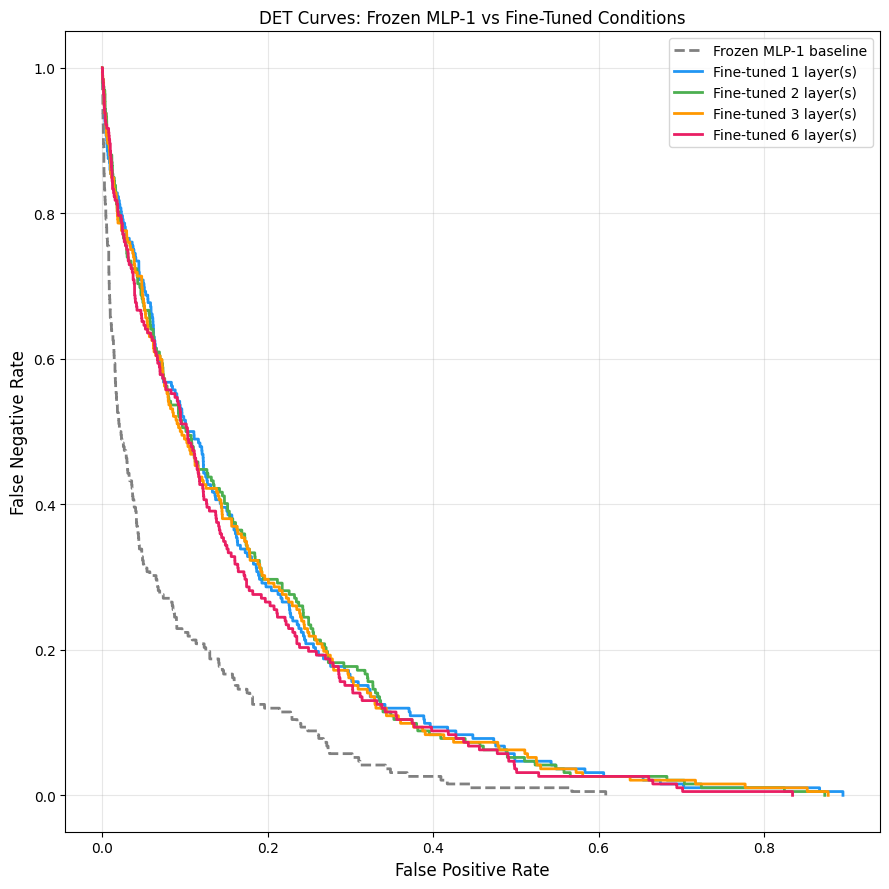

DET curves saved.

Notebook 14 complete.
Fine-tuning underperforms frozen baseline across all conditions.
Root cause: data starvation — 674 positives insufficient
for transformer fine-tuning at this scale.
Stage 2 augmentation experiments not warranted.


In [25]:
# -----------------------------------------------
# Save Stage 1 summary metrics
# -----------------------------------------------
metrics_14 = {
    f"{n}_layers": {
        'precision': round(stage1_results[n]['precision'], 4),
        'recall':    round(stage1_results[n]['recall'], 4),
        'f1':        round(stage1_results[n]['f1'], 4),
        'threshold': round(stage1_results[n]['threshold'], 4),
        'best_cal_f1': round(stage1_results[n]['best_cal_f1'], 4),
    }
    for n in CONDITIONS if n in stage1_results
}

with open(f"{RESULTS_DIR}/metrics_14_finetuning.json", "w") as f:
    json.dump(metrics_14, f, indent=2)
print("Metrics saved.")

# -----------------------------------------------
# DET curves — all conditions vs frozen baseline
# -----------------------------------------------
fig, ax = plt.subplots(figsize=(9, 9))

colors = {1: '#2196F3', 2: '#4CAF50', 3: '#FF9800', 6: '#E91E63'}

# Frozen MLP-1 baseline
from sklearn.linear_model import LogisticRegression
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, input_dim=384, hidden_dims=[256], dropout=0.1):
        super().__init__()
        layers, in_dim = [], input_dim
        for h in hidden_dims:
            layers += [nn.Linear(in_dim, h), nn.ReLU(), nn.Dropout(dropout)]
            in_dim = h
        layers.append(nn.Linear(in_dim, 2))
        self.network = nn.Sequential(*layers)
    def forward(self, x): return self.network(x)

class MLPClassifier:
    def __init__(self, hidden_dims=[256], random_state=42):
        self.hidden_dims = hidden_dims
        self.random_state = random_state
    def fit(self, X, y, X_cal=None, y_cal=None):
        torch.manual_seed(self.random_state)
        self.model_ = MLP(X.shape[1], self.hidden_dims)
        n_neg, n_pos = (y==0).sum(), (y==1).sum()
        w = torch.tensor([1./n_neg, 1./n_pos], dtype=torch.float)
        criterion = nn.CrossEntropyLoss(weight=w)
        opt = torch.optim.AdamW(self.model_.parameters(), lr=1e-3)
        from torch.utils.data import DataLoader, TensorDataset
        loader = DataLoader(
            TensorDataset(torch.tensor(X, dtype=torch.float),
                          torch.tensor(y, dtype=torch.long)),
            batch_size=256, shuffle=True)
        best_f1, best_w, no_imp = 0, None, 0
        for epoch in range(50):
            self.model_.train()
            for xb, yb in loader:
                opt.zero_grad()
                criterion(self.model_(xb), yb).backward()
                opt.step()
            if X_cal is not None:
                s = self.predict_proba(X_cal)[:,1]
                _, f1 = optimal_threshold_f1(y_cal, s)
                if f1 > best_f1:
                    best_f1 = f1
                    best_w = deepcopy(self.model_.state_dict())
                    no_imp = 0
                else:
                    no_imp += 1
                    if no_imp >= 5: break
        if best_w: self.model_.load_state_dict(best_w)
        return self
    def predict_proba(self, X):
        self.model_.eval()
        with torch.no_grad():
            return torch.softmax(
                self.model_(torch.tensor(X, dtype=torch.float)), dim=1
            ).numpy()

def optimal_threshold_f1(y_true, y_scores,
    thresholds=np.arange(0.01, 0.70, 0.01)):
    best_f1, best_t = 0, 0.5
    for t in thresholds:
        preds = (y_scores >= t).astype(int)
        f1 = f1_score(y_true, preds, zero_division=0)
        if f1 > best_f1: best_f1, best_t = f1, t
    return best_t, best_f1

print("Retraining frozen MLP-1 baseline for DET reference...")
clf_base = MLPClassifier(hidden_dims=[256])
clf_base.fit(X_train, y_train, X_cal=X_cal, y_cal=y_cal)
scores_base = clf_base.predict_proba(X_test)[:,1]

fpr, fnr, _ = det_curve(y_test, scores_base)
ax.plot(fpr, fnr, color='gray', linestyle='--',
        linewidth=2, label='Frozen MLP-1 baseline')

for n in CONDITIONS:
    if n not in stage1_results: continue
    fpr, fnr, _ = det_curve(y_test, stage1_results[n]['test_scores'])
    ax.plot(fpr, fnr, color=colors[n], linewidth=2,
            label=f"Fine-tuned {n} layer(s)")

ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("False Negative Rate", fontsize=12)
ax.set_title("DET Curves: Frozen MLP-1 vs Fine-Tuned Conditions",
             fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/det_curves_14.png", dpi=150, bbox_inches='tight')
plt.show()
print("DET curves saved.")

print("\nNotebook 14 complete.")
print("Fine-tuning underperforms frozen baseline across all conditions.")
print("Root cause: data starvation — 674 positives insufficient")
print("for transformer fine-tuning at this scale.")
print("Stage 2 augmentation experiments not warranted.")